# Medical Insurance Cost - Exploratory Data Analysis

## Project Overview

#### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

####Load Dataset

In [ ]:
df = pd.read_csv(r'/content/insurance.csv.zip')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#### Dataset Overview

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

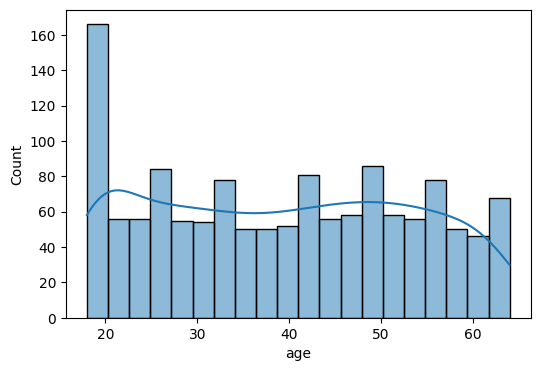

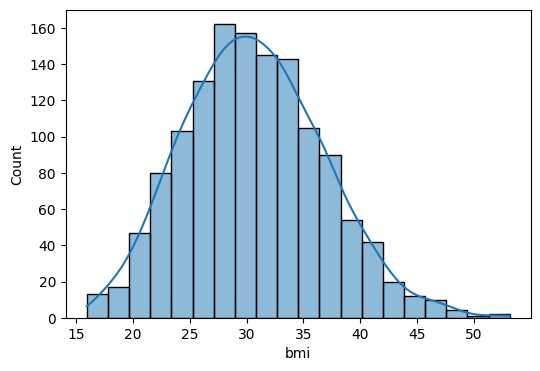

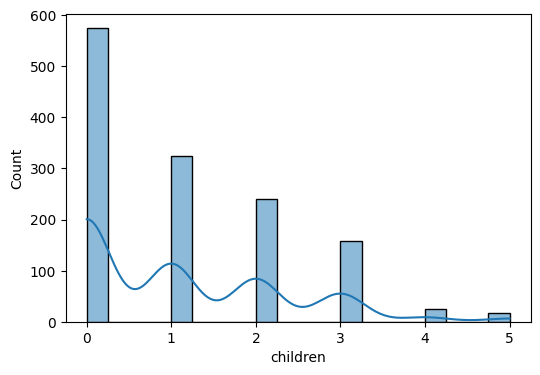

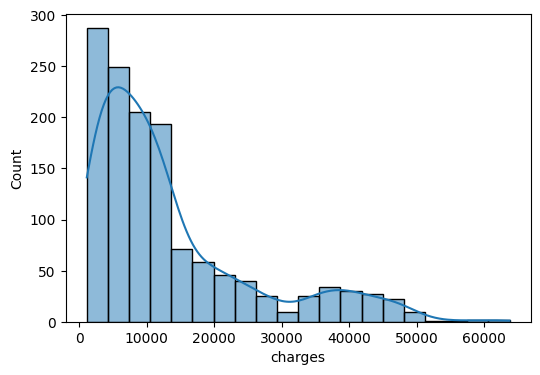

In [ ]:
numeric_columns = [ 'age', 'bmi', 'children','charges']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde = True,bins = 20)

<Axes: xlabel='children', ylabel='count'>

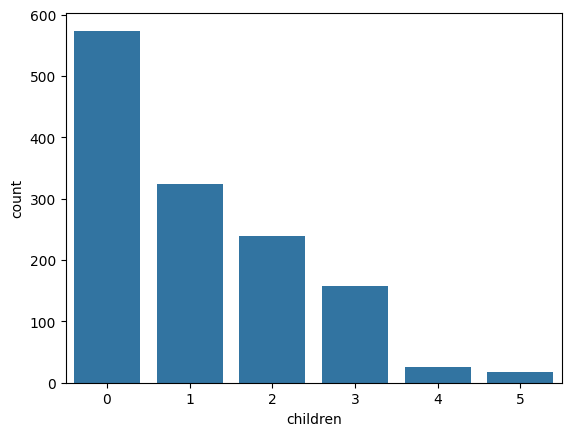

In [ ]:
sns.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

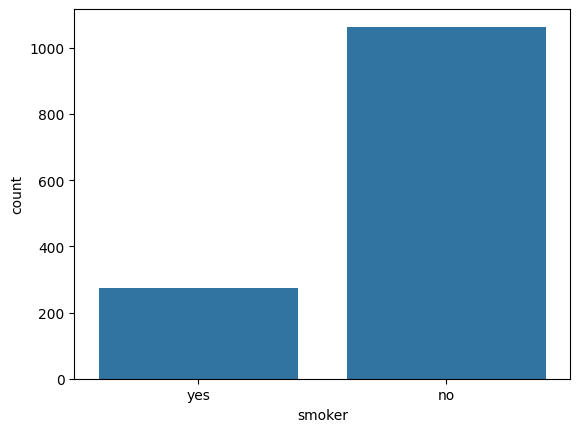

In [ ]:
sns.countplot(x = df['smoker'])

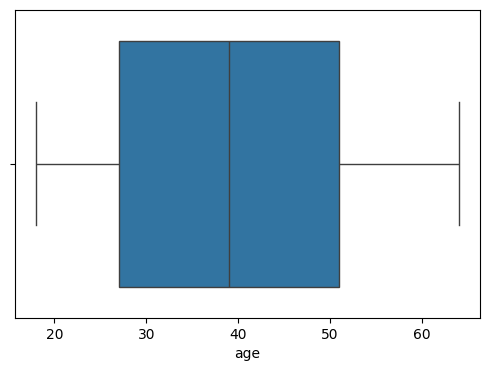

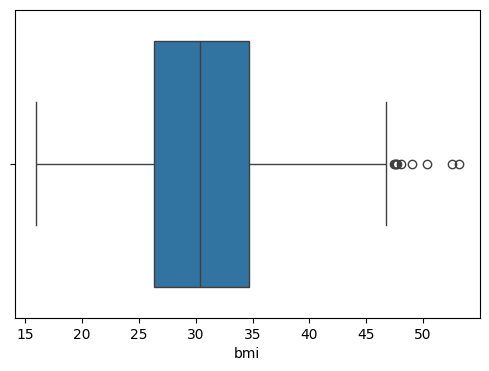

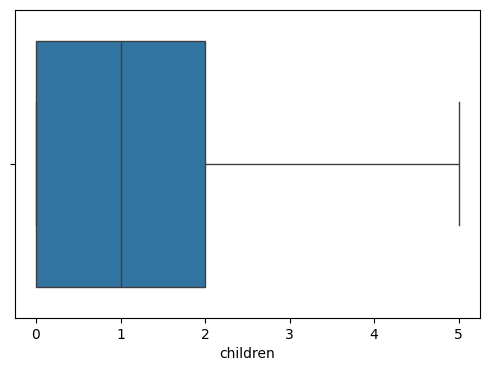

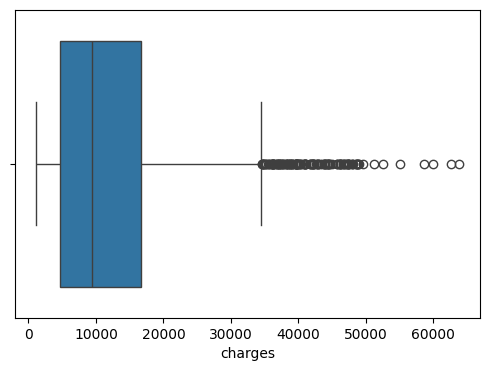

In [ ]:
for col in numeric_columns:
  plt.figure(figsize = (6,4))
  sns.boxplot(x = df[col])

<Axes: xlabel='smoker', ylabel='charges'>

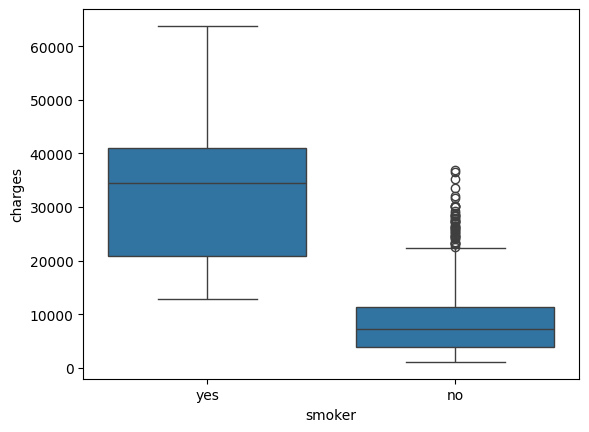

In [ ]:
sns.boxplot(data = df, x = 'smoker', y = 'charges')

### Insight

Insurance charges show a substantial difference between smokers and non-smokers.
Smokers tend to have considerably higher insurance charges, suggesting that
smoking status is an important factor associated with medical insurance costs.

<Axes: xlabel='age', ylabel='charges'>

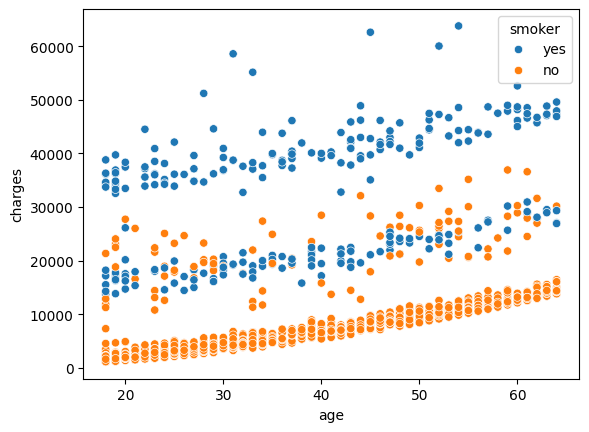

In [ ]:
sns.scatterplot(data = df, x = 'age', y= 'charges', hue = 'smoker')

### Insight

Insurance charges generally tend to increase with age. The relationship is
not purely linear, and the spread of charges becomes more noticeable at
higher ages.

The distinction between smokers and non-smokers also suggests that smoking
status may interact with age when explaining insurance charges.

<Axes: xlabel='bmi', ylabel='charges'>

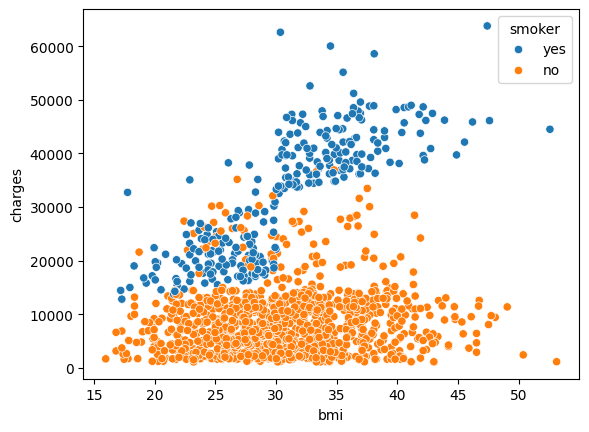

In [ ]:
sns.scatterplot(data = df, x = 'bmi', y = 'charges', hue = 'smoker')

### Insight

BMI shows a positive association with insurance charges, although the
relationship is not uniform across all observations.

The higher concentration of expensive cases among smokers suggests that
smoking status may have a stronger influence on charges than BMI alone.

<Axes: xlabel='region', ylabel='charges'>

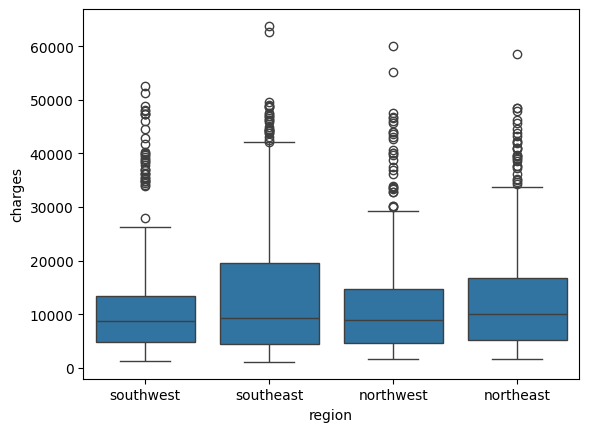

In [ ]:
sns.boxplot(data = df, x = 'region', y = 'charges')

<Axes: xlabel='sex', ylabel='charges'>

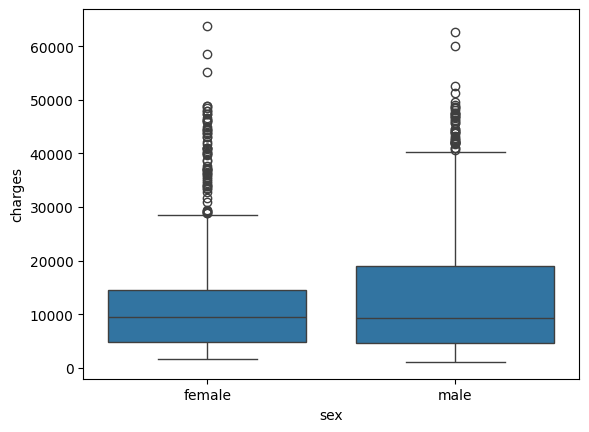

In [ ]:
sns.boxplot(data = df, x = 'sex', y = 'charges')

### Insight

The distribution of insurance charges across males and females shows
considerable overlap. This suggests that sex alone may not be a strong
determinant of insurance charges compared with factors such as smoking
status, age, and BMI.

<Axes: >

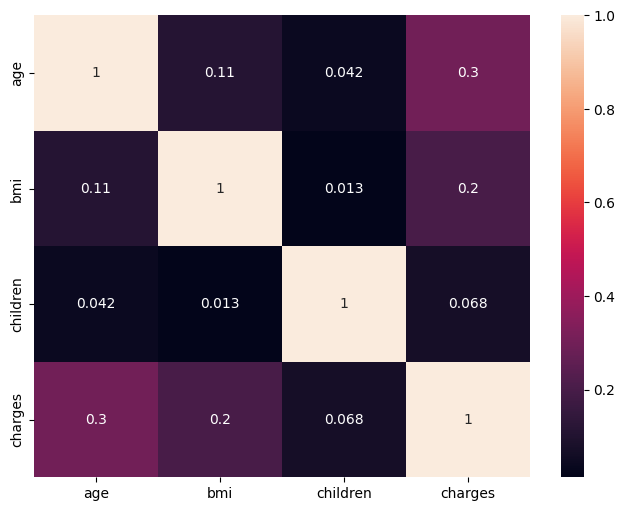

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True)

##Data Cleaning and Preprocessing

In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.shape

(1338, 7)

In [ ]:
df_cleaned.drop_duplicates(inplace = True)

In [ ]:
df_cleaned.shape

(1337, 7)

In [ ]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df_cleaned['sex'].value_counts()

In [ ]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df_cleaned.rename(columns = {
    'sex': 'is_female',
    'smoker':'is_smoker'
}, inplace = True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
# 1- hot encoding

df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'], drop_first = True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [ ]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## Feature Engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

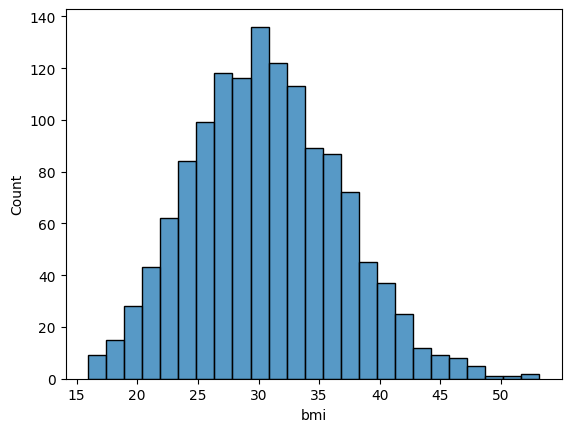

In [ ]:
sns.histplot(df['bmi'])

In [ ]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5, 24.9, 29.9, float('inf')],
    labels = ['underweight', 'normal', 'overweight', 'obese']
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,bmi_category
0,19,1,27,0,1,16884,0,0,1,False,True,False,overweight
1,18,0,33,1,0,1725,0,1,0,False,False,True,obese
2,28,0,33,3,0,4449,0,1,0,False,False,True,obese
3,33,0,22,0,0,21984,1,0,0,True,False,False,normal
4,32,0,28,0,0,3866,1,0,0,False,True,False,overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['bmi_category'], drop_first = True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False,False,True,False


In [ ]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0,0,1,0


In [ ]:
# @title
# Sclaing, its necessary in cases where output depends on weight on input

from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,0,1,0


## Correlation Analysis

In [ ]:
from scipy.stats import pearsonr
import pandas as pd


# Pearson Correlation Calculation

df_cleaned_unique_cols = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese']

available_selected_features = [f for f in selected_features if f in df_cleaned_unique_cols.columns]

correlations = {
    feature: pearsonr(df_cleaned_unique_cols[feature], df_cleaned_unique_cols['charges'])[0]
    for feature in available_selected_features}

correlation_df = pd.DataFrame(list(correlations.items()), columns = ['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by = 'Pearson Correlation', ascending = False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_normal,-0.104042


### Corrrelation with Insurance Charges

Pearson correlation is used to examine the linear relationship betweeen numerical/features and insurance charges.

A higher absolute correlation indicates a stronger linear association, while correlation does not imply causation.

## Statistical Feature Analysis

In [ ]:
cat_featres = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southwest', 'bmi_category_normal',
    'bmi_category_overweight', 'bmi_category_obese']

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned = df.copy()

df_cleaned.drop_duplicates(inplace=True)

# Map 'sex' and 'smoker' to numerical values
df_cleaned['sex'] = df_cleaned['sex'].map({'male': 0, 'female': 1})
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})

df_cleaned.rename(columns={
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace=True)

# One-hot encode 'region'
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

# Create 'bmi_category' and then one-hot encode it
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese'])

df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

# Convert all boolean columns (from get_dummies) to int.

df_cleaned = df_cleaned.astype(int)
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q = 4, labels = False)
chi2_results = {}

cat_featres = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

for col in cat_featres:

  if col in df_cleaned.columns:
    contingency  = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null(keep feature)'if p_val < alpha else 'fail to reject Null'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'decision': decision
    }
  else:
    print(f"Warning: Column '{col}' not found in df_cleaned. Skipping this feature.")

if 'charges_bin' in df_cleaned.columns:
  df_cleaned.drop(columns = ['charges_bin'], inplace = True)

chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df.sort_values(by = 'p_value', ascending = True)

,chi2_statistic,p_value,decision
is_smoker,848.219178,0.0,Reject Null(keep feature)
is_female,10.258784,0.01649,Reject Null(keep feature)
bmi_category_obese,7.654464,0.05372,fail to reject Null
region_southwest,5.091893,0.165191,fail to reject Null
bmi_category_normal,4.263673,0.234364,fail to reject Null
bmi_category_overweight,4.201575,0.240504,fail to reject Null
region_northwest,1.13424,0.768815,fail to reject Null


### Chi-Square Test Interpretation

The Chi-square test is used to determine whether the categorical features
have a statistically significant association with the categorized insurance
charges.

Using a significance level of α = 0.05:

- p-value < 0.05 → Reject the null hypothesis and retain the feature.
- p-value ≥ 0.05 → Fail to reject the null hypothesis.

This analysis provides statistical support for selecting categorical
features for further analysis.

## Final Dataset

In [ ]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

### Final Dataset Overview

The final dataset contains the features selected after data cleaning,
feature engineering, correlation analysis, and statistical feature analysis.

The selected features represent demographic, health-related, lifestyle,
regional, and target information relevant to insurance charges.

The final dataset is structured as:

- `age` — standardized age
- `is_female` — encoded sex
- `bmi` — standardized BMI
- `children` — standardized number of children
- `is_smoker` — encoded smoking status
- `charges` — medical insurance charges
- `region_southeast` — encoded regional feature
- `bmi_category_obese` — engineered BMI category feature

This processed dataset can be used as the foundation for further statistical
analysis or a machine-learning model for insurance charge prediction.

In [ ]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
                       'region_southeast','bmi_category_obese']]
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


# Conclusion

This exploratory data analysis examined the factors associated with medical insurance charges through data cleaning, visualization, correlation analysis, feature engineering, and statistical testing.

The analysis indicates that insurance charges are influenced by multiple factors rather than a single variable. Smoking status shows a particularly noticeable relationship with insurance charges, while age and BMI also show meaningful associations. Regional and demographic variables show comparatively weaker or more variable relationships.

Feature engineering was performed to transform categorical variables into numerical representations and to introduce BMI-based categories. Pearson correlation was used to examine linear relationships with insurance charges, while Chi-square testing was used to evaluate associations between categorical features and categorized insurance charges.

After preprocessing and feature selection, the final dataset contains a focused set of demographic, health-related, lifestyle, regional, and target features. This processed dataset provides a suitable foundation for further analysis and can also be used as input for a machine-learning model to predict medical insurance charges.

Overall, the project demonstrates the complete EDA workflow from raw data inspection and cleaning to statistical analysis and preparation of a structured dataset for downstream applications.


